In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from numpy import sqrt
from numpy import argmax

from matplotlib import pyplot

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import precision_recall_curve

# To remove?
from sklearn.preprocessing import label_binarize

In [2]:
df = pd.read_csv("./datasets/Social_Network_Ads.csv")

In [55]:
random_state = 719333

### Sources

- [Roc curve](https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/)
- [Precission - Recall curve](https://stackoverflow.com/a/53974769)
    - [Custom threshold](https://stackoverflow.com/a/74373754)
- [Default threshold Regresión logistica - Scikit learn](https://www.geeksforgeeks.org/data-science/what-is-the-default-threshold-in-sklearn-logistic-regression/)
- [A Gentle Introduction to Threshold-Moving for Imbalanced Classification](https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/#:~:text=The%20decision%20for%20converting%20a,number%20of%20reasons%2C%20such%20as:)
- [Ver este] [Calculating and Setting Thresholds to Optimise Logistic Regression Performance](https://towardsdatascience.com/calculating-and-setting-thresholds-to-optimise-logistic-regression-performance-c77e6d112d7e/)

# Punto 1

Realice un estudio de variables y de limpieza de datos. Analice las clases, están balanceadas, o no? ¿Qué clase 
nos parece más importante de las dos?

*Clase Gender*
| Valor | Cantidad |
| --- | --- |
|Female|    204|
|Male|      196|


*Clase Purchased*
| Valor | Cantidad |
| --- | --- |
|0 |   257|
|1|    143|

*Purchased* es de mayor interés, ya que indica si un usuario dado ha realizado la compra a partir de un anuncio o no.

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    int64  
 1   Gender           400 non-null    object 
 2   Age              400 non-null    float64
 3   EstimatedSalary  400 non-null    float64
 4   Purchased        400 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 15.8+ KB


In [5]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.nunique()

User ID            400
Gender               2
Age                 43
EstimatedSalary    117
Purchased            2
dtype: int64

In [9]:
df.groupby("Gender").size()

Gender
Female    204
Male      196
dtype: int64

In [10]:
df.groupby("Purchased").size()

Purchased
0    257
1    143
dtype: int64

## Un par de funciones útiles

In [12]:
def quantile_info(data, col):
    Q1 = data[col].quantile(0.25)
    Q2 = data[col].quantile(0.5)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    min_IQR = Q1 - 1.5*IQR
    max_IQR = Q3 + 1.5*IQR

    return Q1, Q2, Q3, IQR, min_IQR, max_IQR

In [17]:
def graficar_boxplot(data, col, col_division, titulo, loc='upper right', figsize=(10,4)):
    plt.figure(figsize=figsize)
    sns.boxplot(data=data, y=col, hue=col_division)
    plt.legend(title=titulo, loc=loc)
    plt.show()

In [47]:
def mean_median_mode_std_var(data, col):
    col_data = data[col]
    mean = col_data.mean()
    median = col_data.median()
    mode = col_data.mode()[0]
    std = col_data.std()
    var = col_data.var()
    min_val = col_data.min()
    max_val = col_data.max()

    return mean, median, mode, std, var, min_val, max_val

## Analizo la columna `Age`

No se encontraron outliers ni datos atípicos

In [48]:
mean, median, mode, std, var, min_val, max_val = mean_median_mode_std_var(df, "Age")

print(f"""
    mean:   {mean}
    median: {median}
    mode:   {mode}
    std:    {std}
    var:    {var}
    min:    {min_val}
    max:    {max_val}
    """)


    mean:   37.655
    median: 37.0
    mode:   35.0
    std:    10.482876597307914
    var:    109.89070175438596
    min:    18.0
    max:    60.0
    


In [29]:
Q1, Q2, Q3, IQR, min_IQR, max_IQR = quantile_info(df, "Age")

print(f"""
    Q1:     {Q1}
    Q2:     {Q2}
    Q3:     {Q3}
    IQR:    {IQR}
    Min_IQR:    {min_IQR}
    Max_IQR:    {max_IQR}
    """)


    Q1:     29.75
    Q2:     37.0
    Q3:     46.0
    IQR:    16.25
    Min_IQR:    5.375
    Max_IQR:    70.375
    


In [32]:
df[df["Age"] < math.floor(min_IQR)]["Age"].count()

0

In [33]:
df[df["Age"] > math.ceil(max_IQR)]["Age"].count()

0

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_20216\1899740578.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=titulo, loc=loc)


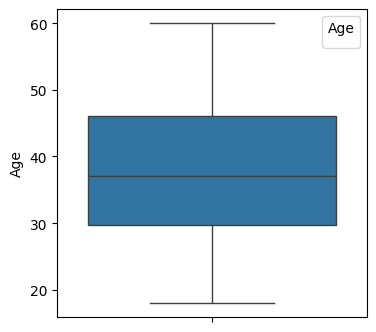

In [20]:
graficar_boxplot(df, "Age", None, "Age", figsize=(4,4))

## Analizo la columna `EstimatedSalary`

No se encontraron datos atípicos ni nulos

In [49]:
mean, median, mode, std, var, min_val, max_val = mean_median_mode_std_var(df, "EstimatedSalary")

print(f"""
    mean:   {mean}
    median: {median}
    mode:   {mode}
    std:    {std}
    var:    {var}
    min:    {min_val}
    max:    {max_val}
    """)


    mean:   69742.5
    median: 70000.0
    mode:   72000.0
    std:    34096.960282424785
    var:    1162602700.5012531
    min:    15000.0
    max:    150000.0
    


In [26]:
Q1, Q2, Q3, IQR, min_IQR, max_IQR = quantile_info(df, "EstimatedSalary")

print(f"""
    Q1:     {Q1}
    Q2:     {Q2}
    Q3:     {Q3}
    IQR:    {IQR}
    Min_IQR:    {min_IQR}
    Max_IQR:    {max_IQR}
    """)


    Q1:     43000.0
    Q2:     70000.0
    Q3:     88000.0
    IQR:    45000.0
    Min_IQR:    -24500.0
    Max_IQR:    155500.0
    


In [ ]:
df[df["EstimatedSalary"] < math.floor(min_IQR)]["EstimatedSalary"].count()

0

In [28]:
df[df["EstimatedSalary"] > math.ceil(max_IQR)]["EstimatedSalary"].count()

0

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_20216\1899740578.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=titulo, loc=loc)


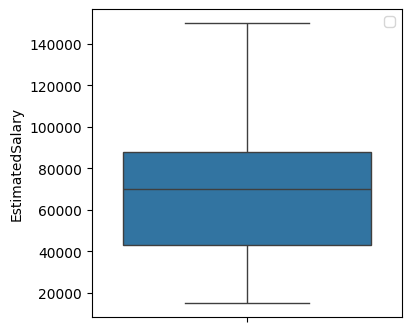

In [23]:
graficar_boxplot(df, "EstimatedSalary", None, None, figsize=(4,4))

## Convertimos categórcias en numéricas

In [64]:
df["Gender_num"] = df["Gender"].apply(lambda x: 0 if x == "Male" else 0)

# Paso 2

In [50]:
df.columns.tolist()

['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']

In [65]:
X = df.loc[:, ["Gender_num", "Age", "EstimatedSalary"]].values
y = df.loc[:, "Purchased"].values

# Paso 3

## Regresión logística

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = random_state, stratify=y)

In [173]:
model_logistic = LogisticRegression(random_state = random_state, class_weight="balanced")
model_logistic.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,719333
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [174]:
y_pred_lr = model_logistic.predict(X_test)

# Creamos la matriz de confusión
cm_logistic = confusion_matrix(y_test, y_pred_lr)

Text(0.5, 1.0, 'Clasificador Regresión Logística')

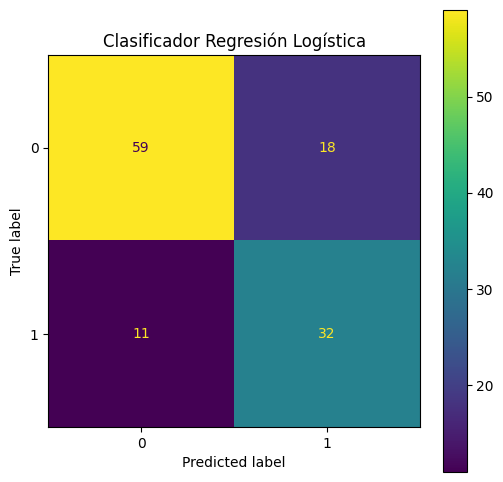

In [175]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic,
                              display_labels=model_logistic.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador Regresión Logística")

In [179]:
# Midamos la sensibilidad y especificidad
print("Clasificador Regresión Logística")
P = np.sum(cm_logistic[1, :])
N = np.sum(cm_logistic[0, :])
TP = cm_logistic[1, 1]
TN = cm_logistic[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred_lr, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred_lr, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred_lr, zero_division=0)}")

Clasificador Regresión Logística
Sensibilidad: 0.7441860465116279
Especificidad: 0.7662337662337663
Exactitud balanceada: 0.7552099063726971
Precision: 0.64
Recuperación: 0.7441860465116279
F1-score: 0.6881720430107527


## KNN

In [78]:
classifier_knn = KNeighborsClassifier(n_neighbors=23, metric="minkowski", p=2)
classifier_knn.fit(X_train, y_train)

,n_neighbors,23
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [79]:
y_pred  = classifier_knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred)

Text(0.5, 1.0, 'Clasificador KNN (23 vecinos)')

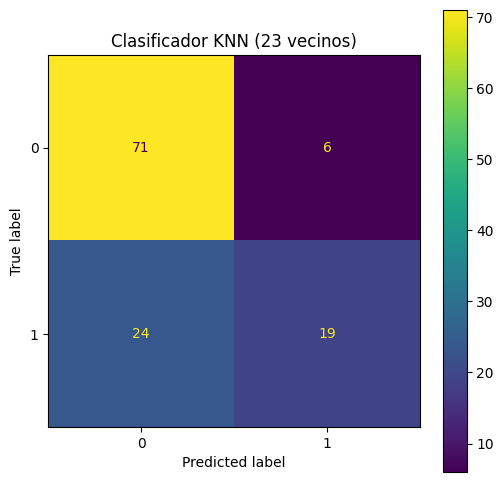

In [80]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=classifier_knn.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador KNN (23 vecinos)")

In [81]:
# Midamos la sensibilidad y especificidad
print("Clasificador KNN (23 vecinos)")
P = np.sum(cm_knn[1, :])
N = np.sum(cm_knn[0, :])
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Clasificador KNN (23 vecinos)
Sensibilidad: 0.4418604651162791
Especificidad: 0.922077922077922
Exactitud balanceada: 0.6819691935971006
Precision: 0.76
Recuperación: 0.4418604651162791
F1-score: 0.5588235294117647


# Paso 4

Clasificador Regresión Logística

- Sensibilidad: 0.7441860465116279
- Especificidad: 0.7662337662337663
- Exactitud balanceada: 0.7552099063726971
- Precision: 0.64
- Recuperación: 0.7441860465116279
- F1-score: 0.6881720430107527

Clasificador KNN (23 vecinos)

- Sensibilidad: 0.4418604651162791
- Especificidad: 0.922077922077922
- Exactitud balanceada: 0.6819691935971006
- Precision: 0.76
- Recuperación: 0.4418604651162791
- F1-score: 0.5588235294117647

# Paso 5

### Búsqueda de mejor threshold

In [424]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr)

roc_auc = auc(fpr, tpr)

roc_auc_s = roc_auc_score(y_test, y_pred_lr)

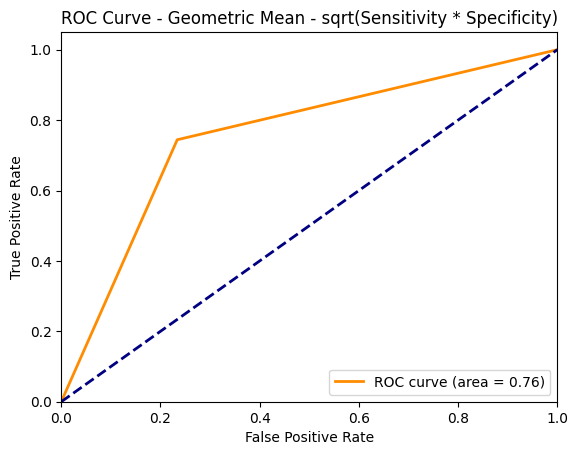

In [425]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_s:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Geometric Mean - sqrt(Sensitivity * Specificity)')
plt.legend(loc="lower right")
plt.show()

In [426]:
y_pred_proba_lr = model_logistic.predict_proba(X_test)[:, 1]

In [427]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr)

roc_auc = auc(fpr, tpr)

roc_auc_s = roc_auc_score(y_test, y_pred_proba_lr)

Best Threshold=0.351639, G-Mean=0.790


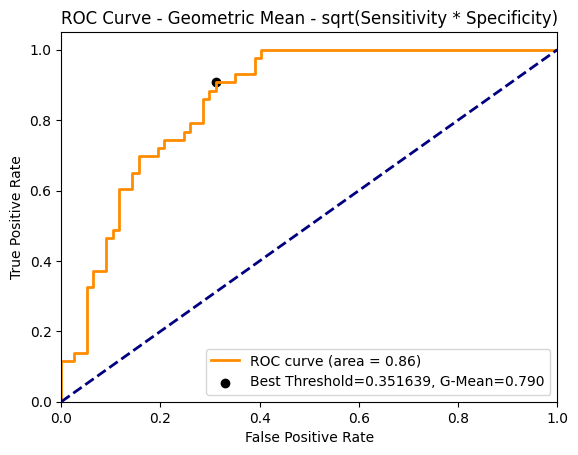

In [428]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_s:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

gmeans = sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = argmax(gmeans)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds[ix], gmeans[ix]))
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best Threshold=%f, G-Mean=%.3f' % (thresholds[ix], gmeans[ix]))


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Geometric Mean - sqrt(Sensitivity * Specificity)')
plt.legend(loc="lower right")
plt.show()

Best Threshold=0.219735


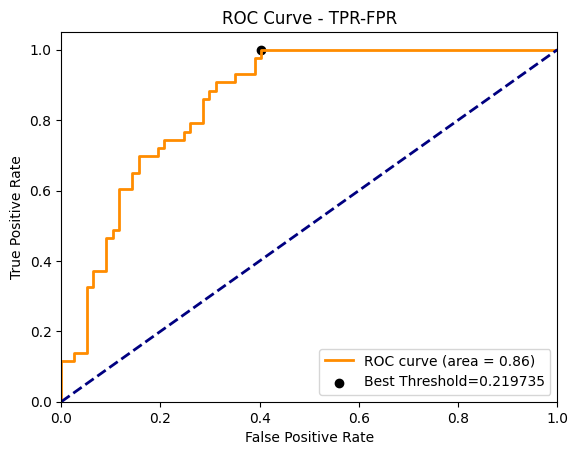

In [429]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_s:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# locate the index of the largest g-mean
ix = argmax(tpr-fpr)
print('Best Threshold=%f' % (thresholds[ix]))
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best Threshold=%f' % (thresholds[ix]))


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TPR-FPR')
plt.legend(loc="lower right")
plt.show()

(0.0, 1.0)

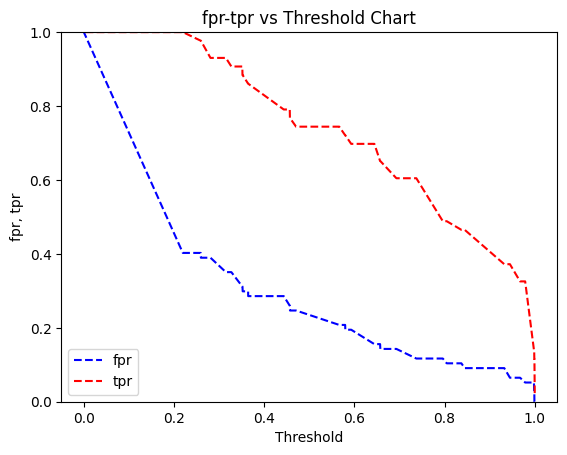

In [430]:
plt.title("fpr-tpr vs Threshold Chart")
plt.plot(thresholds, fpr, "b--", label="fpr")
plt.plot(thresholds, tpr, "r--", label="tpr")
plt.ylabel("fpr, tpr")
plt.xlabel("Threshold")
plt.legend(loc="lower left")
plt.ylim([0,1])

In [431]:
### SOURCE: https://stackoverflow.com/a/53974769
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_lr) 
#retrieve probability of being 1(in second column of probs_y)
pr_auc = auc(recall, precision)

Best Threshold=0.351639, Optimal F1 score:0.735849


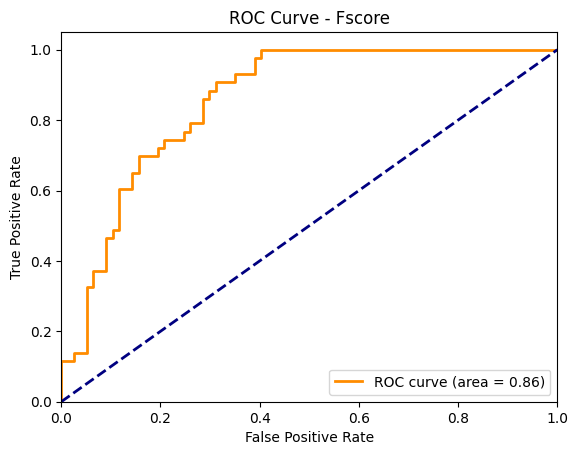

In [432]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_s:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# locate the index of the largest g-mean
fscores = (2 * precision * recall) / (precision + recall)
optimal_idx = np.argmax(fscores)
threshold, optimal_f1_score = thresholds[optimal_idx], fscores[optimal_idx]
print('Best Threshold=%f, Optimal F1 score:%f' % (threshold,optimal_f1_score))
# pyplot.scatter(threshold, optimal_f1_score, marker='o', color='black', label='Best Threshold=%f, Optimal F1 score:%f' % (threshold, optimal_f1_score))


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fscore')
plt.legend(loc="lower right")
plt.show()

(0.0, 1.0)

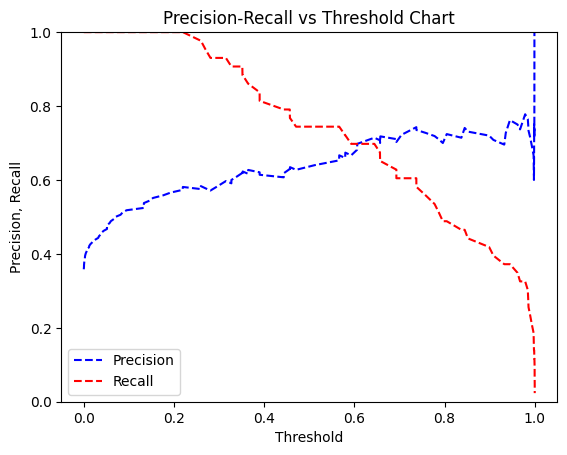

In [433]:
plt.title("Precision-Recall vs Threshold Chart")
plt.plot(thresholds, precision[: -1], "b--", label="Precision")
plt.plot(thresholds, recall[: -1], "r--", label="Recall")
plt.ylabel("Precision, Recall")
plt.xlabel("Threshold")
plt.legend(loc="lower left")
plt.ylim([0,1])

### Modificando el threshold a mano

In [398]:
# Source: https://stackoverflow.com/a/74373754
def custom_predict(probs, threshold):
    return (probs >= threshold).astype(int)

In [399]:
new_threshold = 0.351639
# new_threshold = 0.219735

In [400]:
new_y_pred_proba_lr = custom_predict(probs = y_pred_proba_lr, threshold=new_threshold)

In [401]:
fpr, tpr, thresholds = roc_curve(y_test, new_y_pred_proba_lr)
roc_auc = auc(fpr, tpr)

In [402]:
new_y_pred_proba_lr

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [403]:
# Creamos la matriz de confusión
cm_logistic = confusion_matrix(y_test, new_y_pred_proba_lr)

Text(0.5, 1.0, 'Clasificador Regresión Logística')

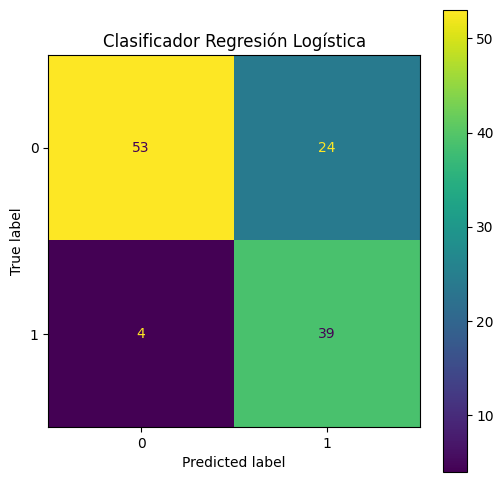

In [404]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic,
                              display_labels=model_logistic.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador Regresión Logística")

In [405]:
# Midamos la sensibilidad y especificidad
print("Clasificador Regresión Logística")
P = np.sum(cm_logistic[1, :])
N = np.sum(cm_logistic[0, :])
TP = cm_logistic[1, 1]
TN = cm_logistic[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, new_y_pred_proba_lr, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, new_y_pred_proba_lr, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, new_y_pred_proba_lr, zero_division=0)}")

Clasificador Regresión Logística
Sensibilidad: 0.9069767441860465
Especificidad: 0.6883116883116883
Exactitud balanceada: 0.7976442162488674
Precision: 0.6190476190476191
Recuperación: 0.9069767441860465
F1-score: 0.7358490566037735


In [406]:
fpr_, tpr_, thresholds_ = roc_curve(y_test, new_y_pred_proba_lr)
roc_auc = auc(fpr_, tpr_)
roc_auc_s = roc_auc_score(y_test, new_y_pred_proba_lr)

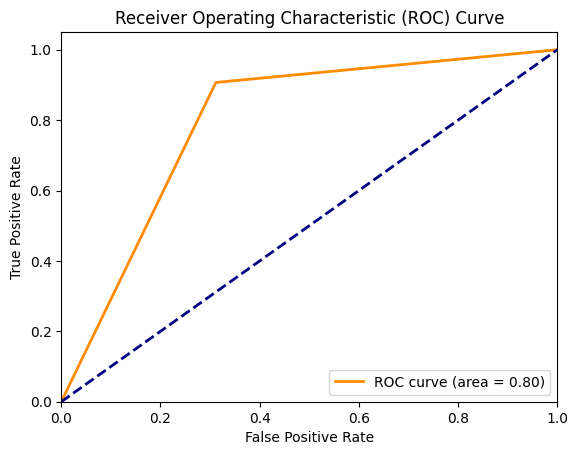

In [407]:
plt.figure()
plt.plot(fpr_, tpr_, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_s:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### Comparación

*Threshold base (0.5)*

- Sensibilidad: 0.7441860465116279
- Especificidad: 0.7662337662337663
- Exactitud balanceada: 0.7552099063726971
- Precision: 0.64
- Recuperación: 0.7441860465116279
- F1-score: 0.6881720430107527

*Threshold G-mean/Fscore= 0.351639*

- Sensibilidad: 0.9069767441860465
- Especificidad: 0.6883116883116883
- Exactitud balanceada: 0.7976442162488674
- Precision: 0.6190476190476191
- Recuperación: 0.9069767441860465
- F1-score: 0.7358490566037735

*Threshold TPR-FPR = 0.219735*

- Sensibilidad: 0.9767441860465116
- Especificidad: 0.5974025974025974
- Exactitud balanceada: 0.7870733917245545
- Precision: 0.5753424657534246
- Recuperación: 0.9767441860465116
- F1-score: 0.7241379310344828